# Team 11 — Data Leakage: Leakage-Prone Experiments

This notebook compares intentional errors against a valid baseline. **The contaminated experiments are demonstrations of invalid evaluation, not valid estimates of real-world performance.** All conditions start from the same deterministic, stratified split so the differences are interpretable.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

RANDOM_STATE = 42
TEST_SIZE = 0.30


In [2]:
# Load bank-full.csv from the same folder as this notebook
# The UCI bank-full.csv file uses semicolon separators.
df = pd.read_csv("bank-full.csv", sep=";")

# Encode the target: yes = 1, no = 0
df["target"] = (df["y"] == "yes").astype(int)

print("Dataset shape:", df.shape)
print("Target distribution:")
print(df["y"].value_counts())
display(df.head())


Dataset shape: (41188, 22)
Target distribution:
y
no     36548
yes     4640
Name: count, dtype: int64


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,target
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0


In [3]:
# Shared, stratified split: preserve class proportions in train and test.
features = ["age", "job", "marital", "education", "housing", "loan", "poutcome"]
X = df[features].copy()
y = df["target"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))
print("Train positive rate:", round(y_train.mean(), 4))
print("Test positive rate:", round(y_test.mean(), 4))


Training rows: 28831
Test rows: 12357
Train positive rate: 0.1127
Test positive rate: 0.1126


In [4]:
def make_model(numeric_features, categorical_features):
    preprocessor = ColumnTransformer([
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ])
    return Pipeline([
        ("preprocessor", preprocessor),
        # Entropy-based Decision Tree; similar criterion to ID3, not a literal ID3 implementation.
        ("classifier", DecisionTreeClassifier(criterion="entropy", random_state=RANDOM_STATE))
    ])

def get_scores(y_true, y_pred, name):
    return {
        "Experiment": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, zero_division=0)
    }


## Experiment B — Prediction-time feature leakage (`duration`)

The split is unchanged and there is no train-test overlap. The deliberate flaw is including call `duration` while claiming to predict before the call begins. It is a timing leak for that intended use case, not necessarily for every possible prediction time.

In [6]:
X_with_duration = df[["age", "job", "marital", "education", "housing", "loan", "poutcome", "duration"]].copy()
X_train_B = X_with_duration.loc[X_train.index]
X_test_B = X_with_duration.loc[X_test.index]

model_B = make_model(
    numeric_features=["age", "duration"],
    categorical_features=["job", "marital", "education", "housing", "loan", "poutcome"]
)
model_B.fit(X_train_B, y_train)
pred_B = model_B.predict(X_test_B)
scores_B = get_scores(y_test, pred_B, "B — Duration included")
print(classification_report(y_test, pred_B, target_names=["No", "Yes"], zero_division=0))


              precision    recall  f1-score   support

          No       0.92      0.92      0.92     10965
         Yes       0.38      0.41      0.39      1392

    accuracy                           0.86     12357
   macro avg       0.65      0.66      0.66     12357
weighted avg       0.86      0.86      0.86     12357



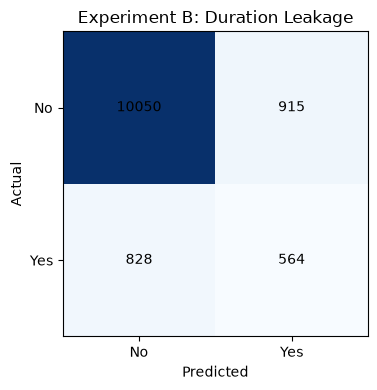

In [7]:
# Confusion matrix for Experiment B: Duration Leakage
cm_B = confusion_matrix(y_test, pred_B)
fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(cm_B, cmap="Blues")
ax.set_title("Experiment B: Duration Leakage", fontsize=12)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_xticks([0, 1], labels=["No", "Yes"])
ax.set_yticks([0, 1], labels=["No", "Yes"])
for (i, j), value in np.ndenumerate(cm_B):
    ax.text(j, i, str(value), ha="center", va="center")
plt.tight_layout()
plt.show()


## Experiment C — Train-test contamination

**Intentional flaw:** append the test records and their labels to the training data, then score on those same test records. This invalidates the test evaluation because the model has already been trained on the test examples. The resulting score must not be reported as genuine generalization performance.

In [8]:
# Intentionally incorrect: test examples and labels are added to training data.
X_train_C = pd.concat([X_train, X_test], axis=0)
y_train_C = pd.concat([y_train, y_test], axis=0)

model_C = make_model(
    numeric_features=["age"],
    categorical_features=["job", "marital", "education", "housing", "loan", "poutcome"]
)
model_C.fit(X_train_C, y_train_C)
pred_C = model_C.predict(X_test)
scores_C = get_scores(y_test, pred_C, "C — Test data included in training (invalid)")
print("WARNING: this score is contaminated and is not a valid test estimate.")
print(classification_report(y_test, pred_C, target_names=["No", "Yes"], zero_division=0))


              precision    recall  f1-score   support

          No       0.93      1.00      0.96     10965
         Yes       0.94      0.37      0.53      1392

    accuracy                           0.93     12357
   macro avg       0.93      0.68      0.75     12357
weighted avg       0.93      0.93      0.91     12357



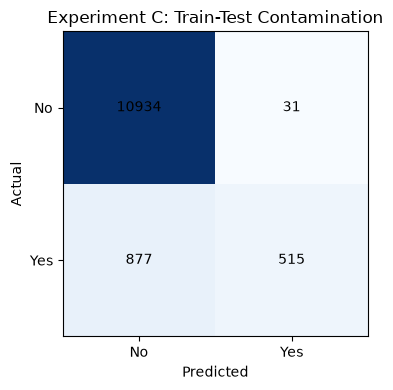

In [10]:
# Confusion matrix for Experiment C: Train-test contamination
cm_C = confusion_matrix(y_test, pred_C)
fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(cm_C, cmap="Blues")
ax.set_title("Experiment C: Train-Test Contamination", fontsize=12)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_xticks([0, 1], labels=["No", "Yes"])
ax.set_yticks([0, 1], labels=["No", "Yes"])
for (i, j), value in np.ndenumerate(cm_C):
    ax.text(j, i, str(value), ha="center", va="center")
plt.tight_layout()
plt.show()


## Experiment D — Combined mistakes

This condition includes `duration` and also trains on the test records and labels. Since both flaws are present, its score cannot isolate the effect of either mistake; compare B and C separately to understand the individual mechanisms.

In [9]:
X_train_D = X_with_duration.loc[X_train.index]
X_test_D = X_with_duration.loc[X_test.index]
X_train_D_leaked = pd.concat([X_train_D, X_test_D], axis=0)
y_train_D_leaked = pd.concat([y_train, y_test], axis=0)

model_D = make_model(
    numeric_features=["age", "duration"],
    categorical_features=["job", "marital", "education", "housing", "loan", "poutcome"]
)
model_D.fit(X_train_D_leaked, y_train_D_leaked)
pred_D = model_D.predict(X_test_D)
scores_D = get_scores(y_test, pred_D, "D — Combined mistakes (invalid)")
print("WARNING: this score is contaminated and is not a valid test estimate.")
print(classification_report(y_test, pred_D, target_names=["No", "Yes"], zero_division=0))


              precision    recall  f1-score   support

          No       1.00      1.00      1.00     10965
         Yes       1.00      0.99      1.00      1392

    accuracy                           1.00     12357
   macro avg       1.00      1.00      1.00     12357
weighted avg       1.00      1.00      1.00     12357



,Accuracy,Precision,Recall,F1-Score
Experiment,,,,
B — Duration included,0.8589,0.3813,0.4052,0.3929
C — Test data included in training (invalid),0.9265,0.9432,0.3700,0.5315
D — Combined mistakes (invalid),0.9992,1.0000,0.9928,0.9964


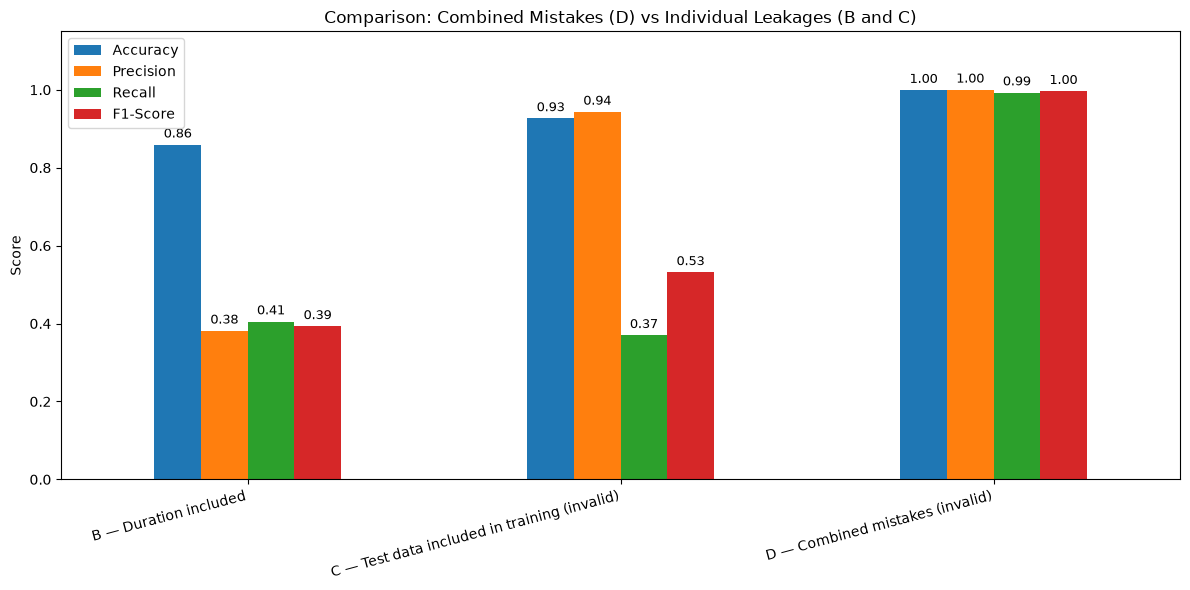

In [11]:
results_bcd = pd.DataFrame([scores_B, scores_C, scores_D])
display(results_bcd.set_index("Experiment").round(4))

metric_names = ["Accuracy", "Precision", "Recall", "F1-Score"]
ax = results_bcd.set_index("Experiment")[metric_names].plot(kind="bar", figsize=(12, 6))
ax.set_title("Comparison: Combined Mistakes (D) vs Individual Leakages (B and C)")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.15) # Increased upper limit to fit labels
ax.set_xlabel("")

# Add values on top of bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3,
        fontsize=9
    )
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()


## Compare Leakage Conditions

Here we compare the individual leakage conditions (B and C) as parts of the combined mistake (D).

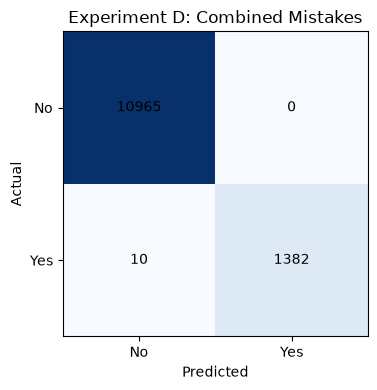

In [12]:
# Confusion matrix for Experiment D: Combined Mistakes (Leakage)
cm_D = confusion_matrix(y_test, pred_D)
fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(cm_D, cmap="Blues")
ax.set_title("Experiment D: Combined Mistakes", fontsize=12)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_xticks([0, 1], labels=["No", "Yes"])
ax.set_yticks([0, 1], labels=["No", "Yes"])
for (i, j), value in np.ndenumerate(cm_D):
    ax.text(j, i, str(value), ha="center", va="center")
plt.tight_layout()
plt.show()


## Conclusion prompts

1. Did adding `duration` change the scores? Explain why that feature is unavailable for a pre-call prediction.
2. Why are C and D not valid estimates of performance on unseen customers?
3. Did leakage improve every metric? Use the observed results, not assumptions.
4. Limitations: one train-test split; one model family; historical data; and a deliberately invalid experiment that illustrates methodology rather than realistic deployment performance.

**Correct practice:** split first, keep the test set untouched, and fit preprocessing and supervised feature selection only on training data. Report the baseline as the valid estimate; never present contaminated scores as legitimate performance.